# Global Terrorism Analysis — 01 Exploratory Data Analysis

An **EDA / visualization** project: global terrorism 1970–2017 — 181,691 attacks from the Global Terrorism Database with country, region, attack type, target, weapon, and perpetrator group. This notebook covers the data overview — shape, types, missing values, and univariate distributions that frame the deeper analysis in notebook 02.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df=utils.load_data()
print('shape:',df.shape)
df.head()

shape: (181691, 15)


,eventid,iyear,imonth,iday,country_txt,region_txt,city,latitude,longitude,success,suicide,attacktype1_txt,targtype1_txt,gname,weaptype1_txt
0,197000000001,1970,7,2,Dominican Republic,Central America & Caribbean,Santo Domingo,18.456792,-69.951164,1,0,Assassination,Private Citizens & Property,MANO-D,Unknown
1,197000000002,1970,0,0,Mexico,North America,Mexico city,19.371887,-99.086624,1,0,Hostage Taking (Kidnapping),Government (Diplomatic),23rd of September Communist League,Unknown
2,197001000001,1970,1,0,Philippines,Southeast Asia,Unknown,15.478598,120.599741,1,0,Assassination,Journalists & Media,Unknown,Unknown
3,197001000002,1970,1,0,Greece,Western Europe,Athens,37.997490,23.762728,1,0,Bombing/Explosion,Government (Diplomatic),Unknown,Explosives
4,197001000003,1970,1,0,Japan,East Asia,Fukouka,33.580412,130.396361,1,0,Facility/Infrastructure Attack,Government (Diplomatic),Unknown,Incendiary


## 1. Structure & dtypes

In [2]:
print(df.dtypes.value_counts().to_dict())
df.info()

{dtype('O'): 7, dtype('int64'): 6, dtype('float64'): 2}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   eventid          181691 non-null  int64  
 1   iyear            181691 non-null  int64  
 2   imonth           181691 non-null  int64  
 3   iday             181691 non-null  int64  
 4   country_txt      181691 non-null  object 
 5   region_txt       181691 non-null  object 
 6   city             181256 non-null  object 
 7   latitude         177135 non-null  float64
 8   longitude        177134 non-null  float64
 9   success          181691 non-null  int64  
 10  suicide          181691 non-null  int64  
 11  attacktype1_txt  181691 non-null  object 
 12  targtype1_txt    181691 non-null  object 
 13  gname            181691 non-null  object 
 14  weaptype1_txt    181691 non-null  object 
dtypes: float64(2), int64(6), obje

## 2. Missing values

In [3]:
mr=utils.missing_report(df)
print('columns with missing values:',len(mr))
print(mr.head(10).to_string())

columns with missing values: 3
           missing   pct
longitude     4557  2.51
latitude      4556  2.51
city           435  0.24


## 3. Numeric distributions

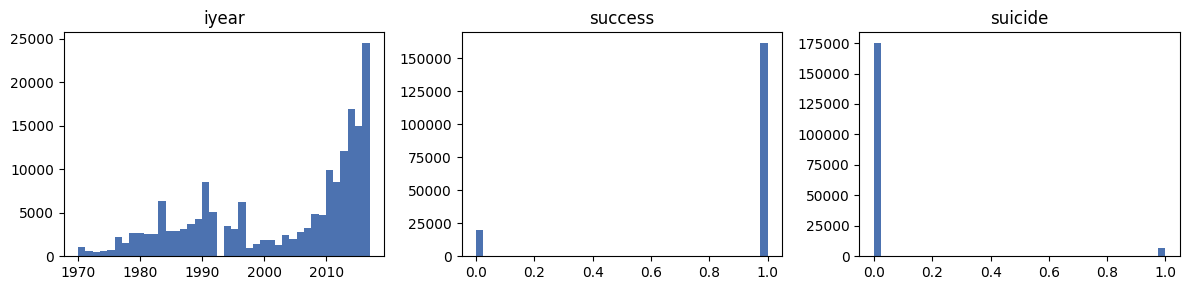

,iyear,success,suicide
count,181691.00,181691.00,181691.00
mean,2002.64,0.89,0.04
std,13.26,0.31,0.19
min,1970.00,0.00,0.00
25%,1991.00,1.00,0.00
50%,2009.00,1.00,0.00
75%,2014.00,1.00,0.00
max,2017.00,1.00,1.00


In [4]:
num=['iyear', 'success', 'suicide']
num=[c for c in num if c in df.columns]
fig,ax=plt.subplots(1,len(num),figsize=(4*len(num),3))
ax=np.atleast_1d(ax)
for a,c in zip(ax,num):
    a.hist(df[c].dropna(),bins=40,color='#4c72b0'); a.set_title(c)
plt.tight_layout(); plt.show()
df[num].describe().round(2)

## 4. Top categories

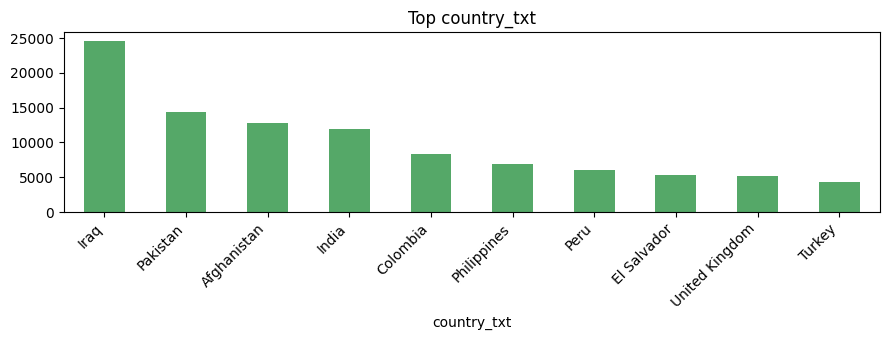

country_txt
Iraq              24636
Pakistan          14368
Afghanistan       12731
India             11960
Colombia           8306
Philippines        6908
Peru               6096
El Salvador        5320
United Kingdom     5235
Turkey             4292


In [5]:
vc=utils.top_counts(df['country_txt'],10)
fig,ax=plt.subplots(figsize=(9,3.5)); vc.plot(kind='bar',ax=ax,color='#55a868'); ax.set_title('Top country_txt'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 5. Summary

The overview above frames the domain questions answered in notebook **02 — Analysis**, where the real insights and the headline numbers (reported in the README) come from.